# MFIS[1-4] +DMO $\rightarrow$ MFIS[5]

In [26]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.pipeline import dmo_for_random_forest
from src.model import DMORandomForestRegressor
from src.evaluation import Evaluation

import torch

In [27]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [ ]:
dmo_features = [
    "cadence_30_p90_d",
    "cadence_30_avg_d",
    "ws_30_p90_d",
    "strlen_1030_avg_d",
    "cadence_all_avg_d",
]

In [28]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [29]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [30]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [31]:
dmo_labels.shape

torch.Size([280, 5, 1])

In [32]:
fatigue_values = dmo_labels.flatten(start_dim=1, end_dim=2)
fatigue_values.shape

torch.Size([280, 5])

In [33]:
dmo_data = dmo_data.mean(axis=2)
dmo_data = dmo_data[:, 1:]

In [34]:
dmo_data.shape

torch.Size([280, 4, 25])

In [35]:
fatigue_values = fatigue_values[:, :-1]
fatigue_values.shape

torch.Size([280, 4])

In [36]:
fatigue_labels = dmo_labels[:, -1]
fatigue_labels.shape

torch.Size([280, 1])

In [37]:
fatigue_values = fatigue_values.unsqueeze(dim=2)

In [38]:
fatigue_values.shape

torch.Size([280, 4, 1])

In [39]:
input_data = torch.concatenate((dmo_data, fatigue_values), dim=2)
input_data.shape

torch.Size([280, 4, 26])

In [40]:
input_data = input_data.flatten(start_dim=1, end_dim=2)
input_data.shape

torch.Size([280, 104])

In [41]:
fatigue_labels.shape

torch.Size([280, 1])

In [42]:
transforms = (None, None)
train, test = dmo_for_random_forest(input_data, fatigue_labels, transforms, normalise=False)

train_input, train_label = train
test_input, test_label = test

In [43]:
train_label = train_label.squeeze()
test_label = test_label.squeeze()

In [44]:
rf_model = DMORandomForestRegressor(n_trees=500)

rf_model.train(train_input, train_label)
score = rf_model.score(test_input, test_label)
print(score)

0.5154572631112588


{'accuracy': 0.05357142857142857, 'Mean Squared Error': 33.479801177978516, 'Mean Absolute Error': 4.355678558349609, 'R^2': 0.5154572980514469}


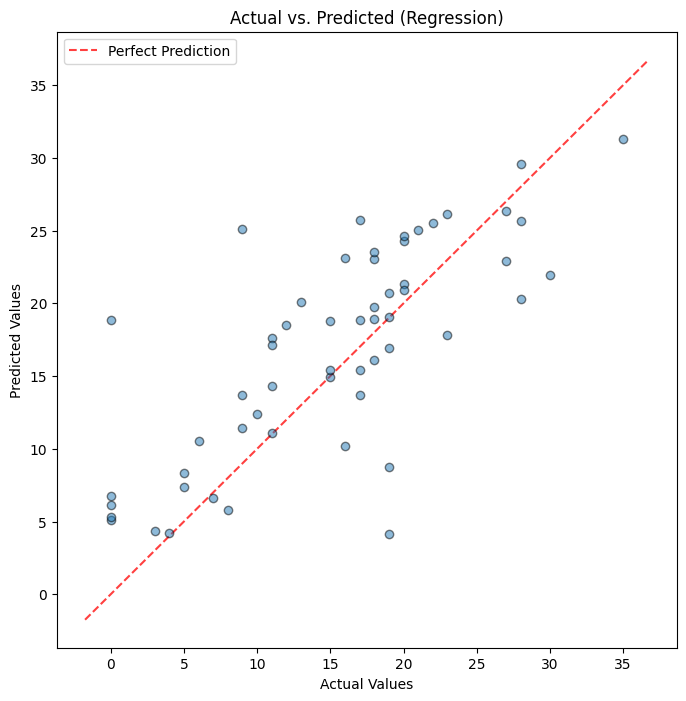

In [45]:
prediction = torch.tensor(rf_model.predict(test_input))
prediction.shape
actual = test_label
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

['wb_all_sum', 'walkdur_all_sum', 'wbsteps_all_sum', 'wbdur_all_avg', 'wbdur_all_p90', 'wbdur_all_var', 'cadence_all_avg', 'strdur_all_avg', 'cadence_all_var', 'strdur_all_var', 'ws_1030_avg', 'strlen_1030_avg', 'wb_10_sum', 'ws_10_p90', 'wb_30_sum', 'ws_30_avg', 'strlen_30_avg', 'cadence_30_avg', 'strdur_30_avg', 'ws_30_p90', 'cadence_30_p90', 'ws_30_var', 'strlen_30_var', 'wb_60_sum', 'total_worn_h', 'MFISV1', 'wb_all_sum', 'walkdur_all_sum', 'wbsteps_all_sum', 'wbdur_all_avg', 'wbdur_all_p90', 'wbdur_all_var', 'cadence_all_avg', 'strdur_all_avg', 'cadence_all_var', 'strdur_all_var', 'ws_1030_avg', 'strlen_1030_avg', 'wb_10_sum', 'ws_10_p90', 'wb_30_sum', 'ws_30_avg', 'strlen_30_avg', 'cadence_30_avg', 'strdur_30_avg', 'ws_30_p90', 'cadence_30_p90', 'ws_30_var', 'strlen_30_var', 'wb_60_sum', 'total_worn_h', 'MFISV2', 'wb_all_sum', 'walkdur_all_sum', 'wbsteps_all_sum', 'wbdur_all_avg', 'wbdur_all_p90', 'wbdur_all_var', 'cadence_all_avg', 'strdur_all_avg', 'cadence_all_var', 'strdur_al

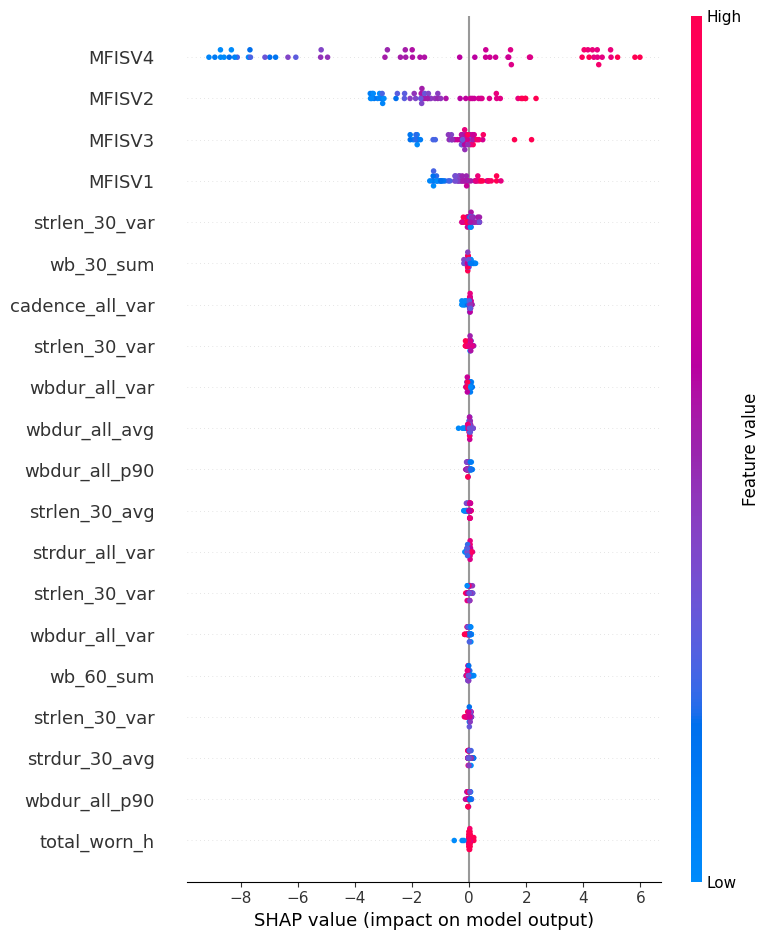

In [51]:
import shap


features = []

for i in range(1, 5):
    features.extend([*dmo_features, f"MFISV{i}"])

print(features)
random_forest_model = rf_model.random_forest
test_input_numpy = torch.Tensor.numpy(test_input)

explainer = shap.TreeExplainer(random_forest_model)
shap_values = explainer.shap_values(test_input_numpy)
shap.summary_plot(
    shap_values,
    test_input_numpy,
    feature_names=features,
)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


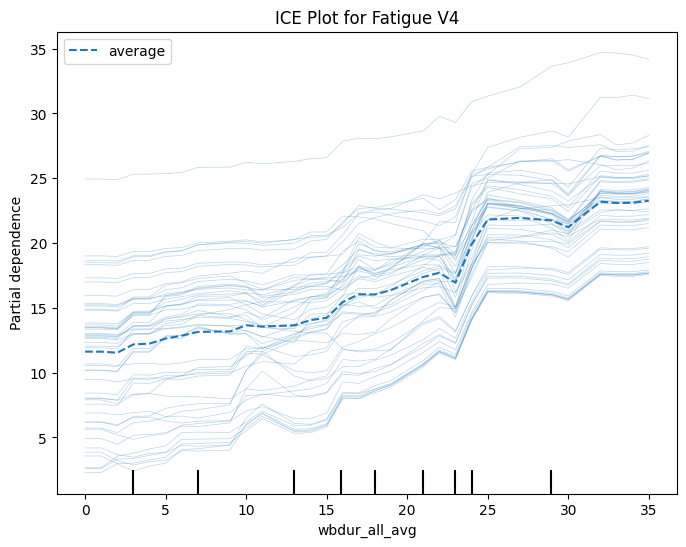

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

feature_index = 3

test_numpy = test_input.numpy()

fig, ax = plt.subplots(figsize=(8, 6))

display = PartialDependenceDisplay.from_estimator(
    random_forest_model, 
    test_numpy, 
    features=[feature_index],
    feature_names=dmo_features,
    kind='both', 
    subsample=50,
    ax=ax
)

ax.set_title("ICE Plot for Fatigue V4")
plt.show()